In [12]:

import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import numpy as np

In [13]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNEL = 3

In [14]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
directory='D:\PROJECTS\Potato Disease Classification\Training\Potato Disease Dataset',
seed=42,
shuffle = True,
image_size=(IMAGE_SIZE,IMAGE_SIZE),
batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [15]:
class_names = dataset.class_names
print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [16]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    dataset_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=42)
    
    train_size = int(train_split * dataset_size)
    val_size = int(val_split * dataset_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [17]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [18]:
model = tf.keras.models.load_model('D:\PROJECTS\Potato Disease Classification\Testing\model.keras')

*****First image to predict : *****
Actual Label : Potato___Late_blight
1/1 [==============================] - 3s 3s/step
Predicted Label : Potato___Late_blight


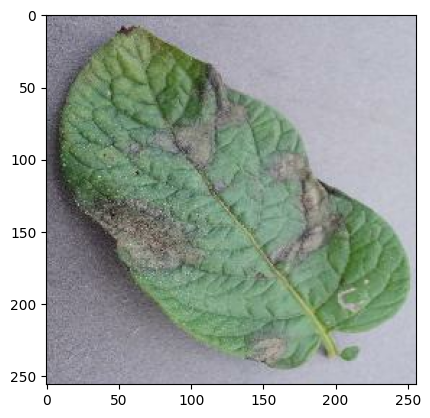

In [19]:
for images_batch, label_batch in test_ds.take(1):
    image = images_batch[0].numpy().astype('uint8')
    label = label_batch[0].numpy()

    print(f"*****First image to predict : *****")
    plt.imshow(image)
    print(f"Actual Label : {class_names[label]}")

    # Expand dimensions to match model input shape
    image = np.expand_dims(image, axis=0)  

    prediction = model.predict(image)
    print(f"Predicted Label : {class_names[np.argmax(prediction[0])]}")  

1/1 [==============================] - 0s 30ms/step
📊 Classification Report:

Potato___Early_blight: Precision=0.97, Recall=1.00, F1-score=0.98, Support=129.0
Potato___Late_blight: Precision=0.99, Recall=0.96, F1-score=0.97, Support=114.0
Potato___healthy: Precision=0.92, Recall=0.92, F1-score=0.92, Support=13.0
macro avg: Precision=0.96, Recall=0.96, F1-score=0.96, Support=256.0
weighted avg: Precision=0.98, Recall=0.98, F1-score=0.98, Support=256.0


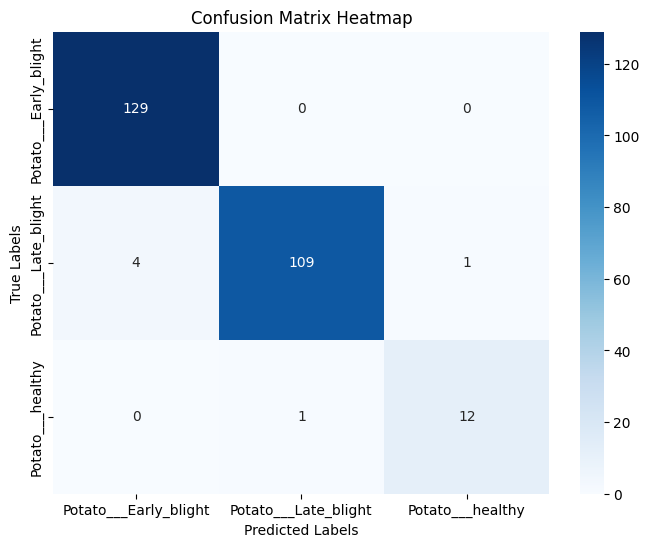

In [20]:
# Get predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())  # True labels
    y_pred.extend(np.argmax(predictions, axis=1))  # Predicted labels

# Generate classification report
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# Print formatted classification report
print("📊 Classification Report:\n")
for label, metrics in report.items():
    if isinstance(metrics, dict):
        print(f"{label}: Precision={metrics['precision']:.2f}, Recall={metrics['recall']:.2f}, F1-score={metrics['f1-score']:.2f}, Support={metrics['support']}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix Heatmap")
plt.show()


In [21]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 19ms/step


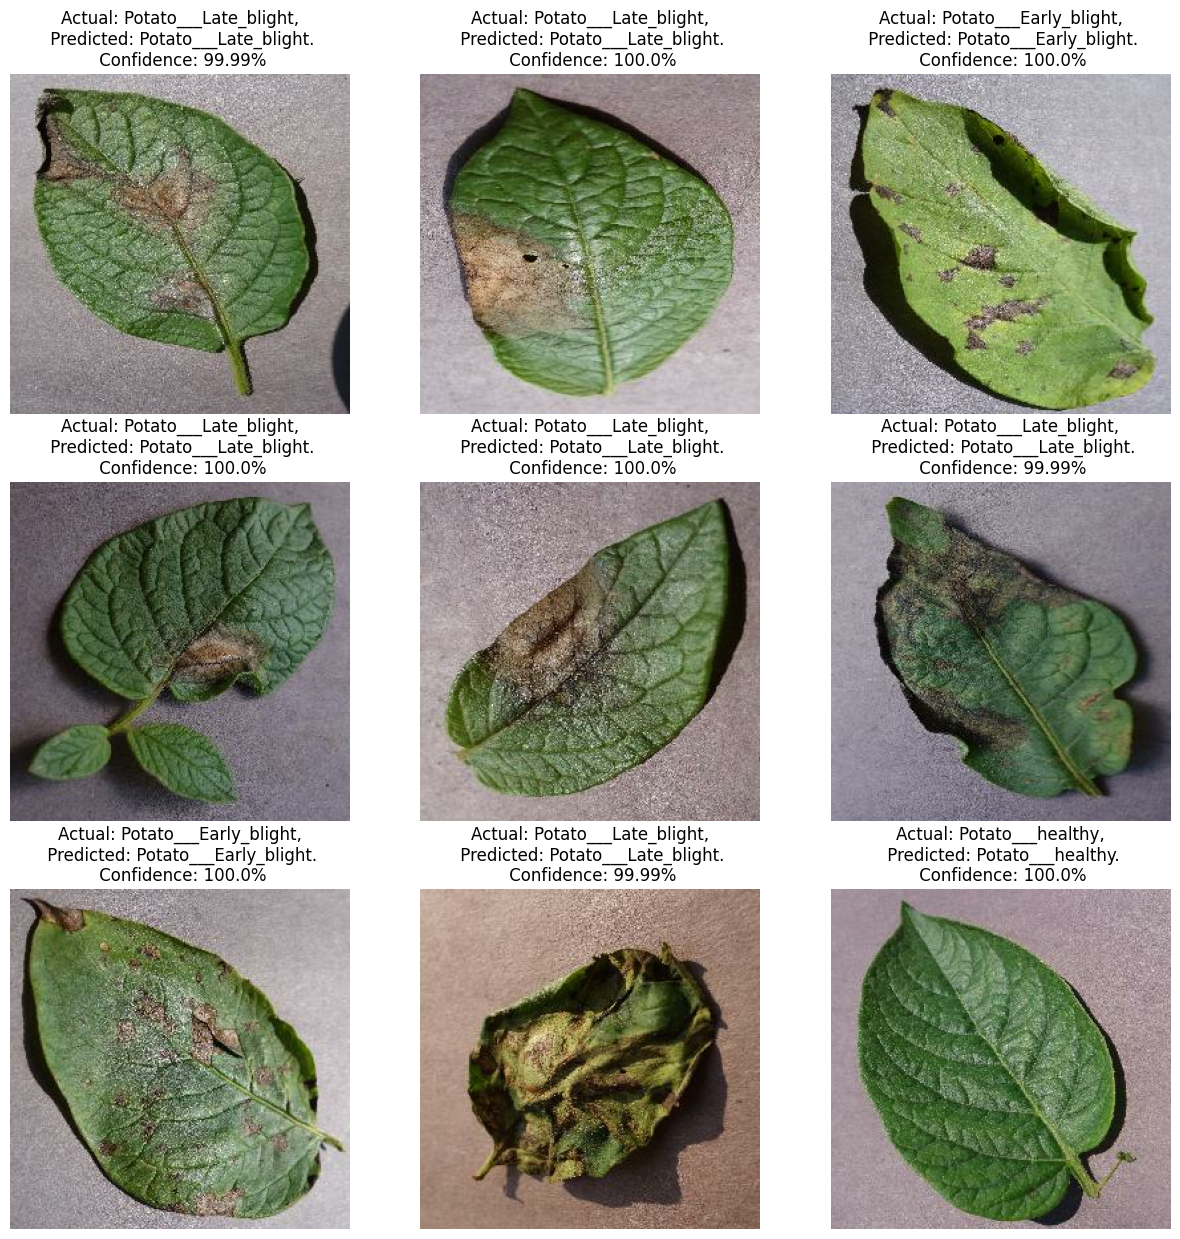

In [22]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

1/1 [==============================] - 0s 30ms/step

📊 Classification Report:

Potato___Early_blight: Precision=0.96, Recall=1.00, F1-score=0.98, Support=116.0
Potato___Late_blight: Precision=1.00, Recall=0.95, F1-score=0.97, Support=110.0
Potato___healthy: Precision=0.97, Recall=1.00, F1-score=0.98, Support=30.0
macro avg: Precision=0.98, Recall=0.98, F1-score=0.98, Support=256.0
weighted avg: Precision=0.98, Recall=0.98, F1-score=0.98, Support=256.0


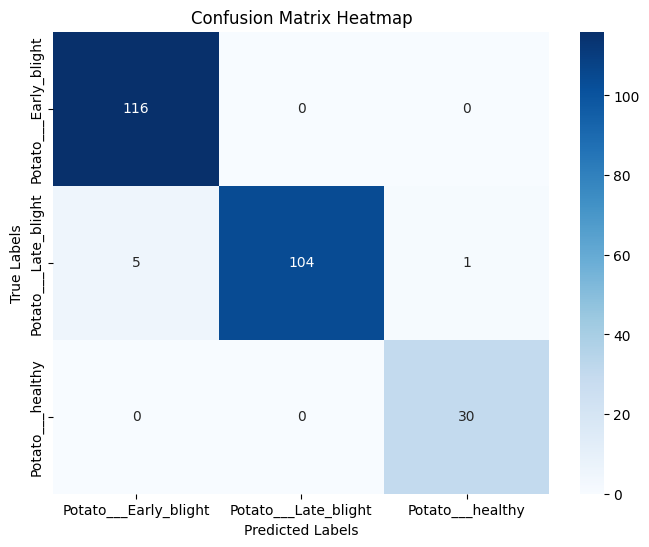

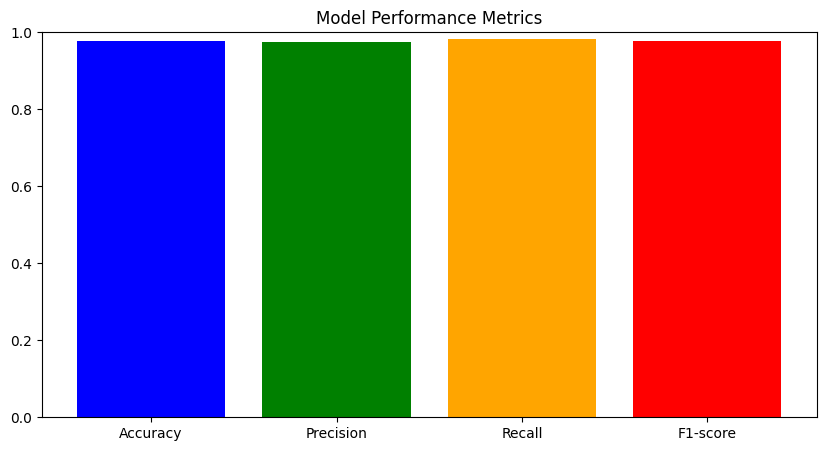

In [23]:

# Initialize true labels and predictions
y_true = []
y_pred = []

# Make predictions on the test dataset
for images, labels in test_ds:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())  # True labels
    y_pred.extend(np.argmax(predictions, axis=1))  # Predicted labels

# Compute classification report
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# Print formatted classification report
print("\n📊 Classification Report:\n")
for label, metrics in report.items():
    if isinstance(metrics, dict):
        print(f"{label}: Precision={metrics['precision']:.2f}, Recall={metrics['recall']:.2f}, "
              f"F1-score={metrics['f1-score']:.2f}, Support={metrics['support']}")

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix Heatmap")
plt.show()

# Plot Model Performance Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = [report[label]['precision'] for label in class_names]
recall = [report[label]['recall'] for label in class_names]
f1_score = [report[label]['f1-score'] for label in class_names]

plt.figure(figsize=(10, 5))
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
values = [accuracy, np.mean(precision), np.mean(recall), np.mean(f1_score)]

plt.bar(metrics, values, color=["blue", "green", "orange", "red"])
plt.ylim(0, 1)
plt.title("Model Performance Metrics")
plt.show()